In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
np.random.seed(42)

n = 2000

disaster_types = np.random.choice(
    ["Flood", "Earthquake", "Fire", "Extreme Weather"],
    size=n
)

data = pd.DataFrame({
    "disaster_type": disaster_types,
    "temperature": np.random.uniform(15, 45, n),
    "rainfall": np.random.uniform(0, 300, n),
    "wind_speed": np.random.uniform(0, 150, n),
    "water_level": np.random.uniform(0, 12, n),
    "earthquake_magnitude": np.random.uniform(0, 8, n),
    "population_density": np.random.uniform(100, 10000, n),
    "distance_from_river": np.random.uniform(0.1, 10, n)
})

data.head()

,disaster_type,temperature,rainfall,wind_speed,water_level,earthquake_magnitude,population_density,distance_from_river
0,Fire,20.553988,201.810898,59.045328,0.465593,7.308624,5377.002559,9.745745
1,Extreme Weather,31.257028,239.004419,71.015349,2.241270,4.202884,1465.198335,0.270013
2,Flood,41.188375,75.140370,128.182109,9.974950,5.799282,5953.304767,9.481751
3,Fire,36.966747,187.462230,51.000658,9.201220,3.488386,3216.377675,3.749906
4,Fire,39.196834,171.523795,130.447453,4.207712,5.040277,618.252791,0.199895


In [4]:
# Calculate disaster-specific risk score

risk_score = np.zeros(len(data))

# Flood risk
flood = data["disaster_type"] == "Flood"
risk_score[flood] = (
    (data.loc[flood, "rainfall"] / 300) * 40 +
    (data.loc[flood, "water_level"] / 12) * 40 +
    (1 - data.loc[flood, "distance_from_river"] / 10) * 20
)

# Earthquake risk
earthquake = data["disaster_type"] == "Earthquake"
risk_score[earthquake] = (
    (data.loc[earthquake, "earthquake_magnitude"] / 8) * 80 +
    (data.loc[earthquake, "population_density"] / 10000) * 20
)

# Fire risk
fire = data["disaster_type"] == "Fire"
risk_score[fire] = (
    (data.loc[fire, "temperature"] / 45) * 45 +
    (data.loc[fire, "wind_speed"] / 150) * 35 +
    (data.loc[fire, "population_density"] / 10000) * 20
)

# Extreme weather risk
extreme = data["disaster_type"] == "Extreme Weather"
risk_score[extreme] = (
    (data.loc[extreme, "wind_speed"] / 150) * 40 +
    (data.loc[extreme, "rainfall"] / 300) * 30 +
    (data.loc[extreme, "temperature"] / 45) * 30
)

data["risk_score"] = risk_score

# Convert score into risk category
data["risk_level"] = pd.cut(
    data["risk_score"],
    bins=[-1, 30, 60, 100],
    labels=["Low", "Medium", "High"]
)

data.head()

,disaster_type,temperature,rainfall,wind_speed,water_level,earthquake_magnitude,population_density,distance_from_river,risk_score,risk_level
0,Fire,20.553988,201.810898,59.045328,0.465593,7.308624,5377.002559,9.745745,45.085236,Medium
1,Extreme Weather,31.257028,239.004419,71.015349,2.241270,4.202884,1465.198335,0.270013,63.675887,High
2,Flood,41.188375,75.140370,128.182109,9.974950,5.799282,5953.304767,9.481751,44.305045,Medium
3,Fire,36.966747,187.462230,51.000658,9.201220,3.488386,3216.377675,3.749906,55.299655,Medium
4,Fire,39.196834,171.523795,130.447453,4.207712,5.040277,618.252791,0.199895,70.871079,High


In [5]:
print(data["risk_level"].value_counts())

risk_level
Medium    1035
High       720
Low        245
Name: count, dtype: int64


In [6]:
# Prepare features and target

X = data.drop(columns=["risk_level", "risk_score"])
y = data["risk_level"]

# Convert disaster type into numerical columns
X = pd.get_dummies(X, columns=["disaster_type"], dtype=int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (2000, 11)
Target shape: (2000,)


,temperature,rainfall,wind_speed,water_level,earthquake_magnitude,population_density,distance_from_river,disaster_type_Earthquake,disaster_type_Extreme Weather,disaster_type_Fire,disaster_type_Flood
0,20.553988,201.810898,59.045328,0.465593,7.308624,5377.002559,9.745745,0,0,1,0
1,31.257028,239.004419,71.015349,2.241270,4.202884,1465.198335,0.270013,0,1,0,0
2,41.188375,75.140370,128.182109,9.974950,5.799282,5953.304767,9.481751,0,0,0,1
3,36.966747,187.462230,51.000658,9.201220,3.488386,3216.377675,3.749906,0,0,1,0
4,39.196834,171.523795,130.447453,4.207712,5.040277,618.252791,0.199895,0,0,1,0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
    random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [9]:
# Make predictions on test data

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 89.75%


In [10]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

        High       0.95      0.88      0.92       144
         Low       0.94      0.67      0.79        49
      Medium       0.86      0.96      0.91       207

    accuracy                           0.90       400
   macro avg       0.92      0.84      0.87       400
weighted avg       0.90      0.90      0.90       400



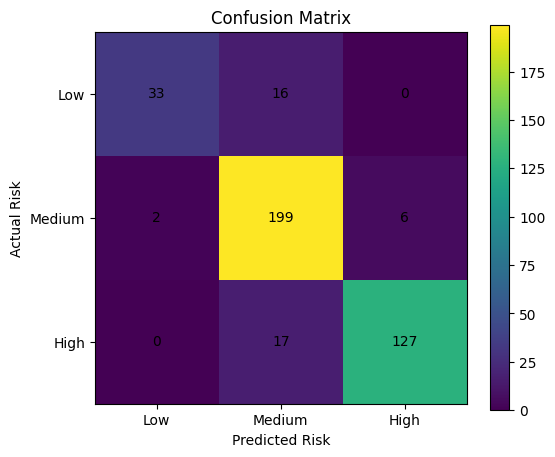

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.xticks(
    range(3),
    ["Low", "Medium", "High"]
)

plt.yticks(
    range(3),
    ["Low", "Medium", "High"]
)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

earthquake_magnitude             0.179385
wind_speed                       0.156688
rainfall                         0.134108
temperature                      0.110732
water_level                      0.102549
population_density               0.092437
distance_from_river              0.073858
disaster_type_Earthquake         0.061056
disaster_type_Flood              0.041269
disaster_type_Fire               0.025356
disaster_type_Extreme Weather    0.022563
dtype: float64


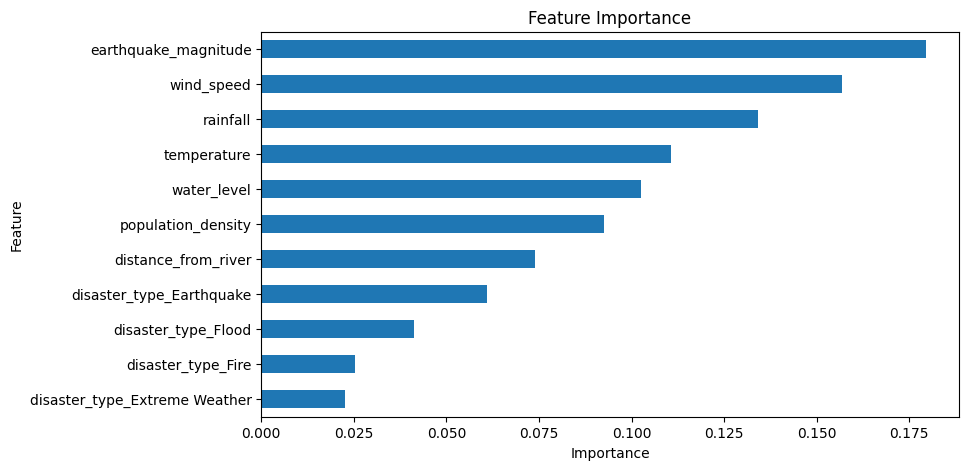

In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(9, 5))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [18]:
def disaster_assistant(
    disaster_type,
    temperature,
    rainfall,
    wind_speed,
    water_level,
    earthquake_magnitude,
    population_density,
    distance_from_river
):

    # Create input in the same format used during training
    input_data = pd.DataFrame({
        "disaster_type": [disaster_type],
        "temperature": [temperature],
        "rainfall": [rainfall],
        "wind_speed": [wind_speed],
        "water_level": [water_level],
        "earthquake_magnitude": [earthquake_magnitude],
        "population_density": [population_density],
        "distance_from_river": [distance_from_river]
    })

    # One-hot encode disaster type
    input_data = pd.get_dummies(
        input_data,
        columns=["disaster_type"],
        dtype=int
    )

    # Make sure input has exactly the same columns as training data
    input_data = input_data.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Predict risk
    prediction = model.predict(input_data)[0]

    # Emergency recommendations
    recommendations = {
        "Low": "🟢 Situation appears relatively stable. Continue monitoring disaster conditions.",

        "Medium": "🟡 Moderate risk detected. Stay alert, monitor official warnings, and keep emergency supplies ready.",

        "High": "🔴 HIGH RISK detected! Follow official emergency instructions, move to a safer location if advised, and contact emergency services when necessary."
    }

    print("=" * 55)
    print("AI DISASTER ASSISTANT")
    print("=" * 55)

    print(f"Disaster Type : {disaster_type}")
    print(f"Risk Level    : {prediction}")

    print("\n🚨 Emergency Recommendation:")
    print(recommendations[prediction])

    print("=" * 55)

In [19]:
disaster_assistant(
    disaster_type="Flood",
    temperature=30,
    rainfall=280,
    wind_speed=80,
    water_level=10,
    earthquake_magnitude=1,
    population_density=8500,
    distance_from_river=0.5
)

AI DISASTER ASSISTANT
Disaster Type : Flood
Risk Level    : High

🚨 Emergency Recommendation:
🔴 HIGH RISK detected! Follow official emergency instructions, move to a safer location if advised, and contact emergency services when necessary.


In [20]:
disaster_assistant(
    disaster_type="Flood",
    temperature=25,
    rainfall=20,
    wind_speed=15,
    water_level=1,
    earthquake_magnitude=1,
    population_density=500,
    distance_from_river=8
)

AI DISASTER ASSISTANT
Disaster Type : Flood
Risk Level    : Low

🚨 Emergency Recommendation:
🟢 Situation appears relatively stable. Continue monitoring disaster conditions.


In [17]:
# 🌍 AI DISASTER ASSISTANT - SMART USER INPUT

print("=" * 60)
print(" AI DISASTER ASSISTANT")
print("=" * 60)

print("\nSelect Disaster Type:")
print("1. Flood")
print("2. Earthquake")
print("3. Fire")
print("4. Extreme Weather")

choice = int(input("\nEnter your choice (1-4): "))

disaster_types = {
    1: "Flood",
    2: "Earthquake",
    3: "Fire",
    4: "Extreme Weather"
}

if choice not in disaster_types:
    print("Invalid choice!")
else:

    disaster_type = disaster_types[choice]

    print(f"\nSelected Disaster: {disaster_type}")
    print("-" * 60)

    # Default values for all model features
    temperature = 25
    rainfall = 0
    wind_speed = 0
    water_level = 0
    earthquake_magnitude = 0
    population_density = 1000
    distance_from_river = 10

    # ---------------- FLOOD ----------------
    if disaster_type == "Flood":

        rainfall = float(input("Enter rainfall (mm): "))
        water_level = float(input("Enter water level (m): "))
        distance_from_river = float(
            input("Enter distance from river (km): ")
        )
        population_density = float(
            input("Enter population density (people/km²): ")
        )

    # ---------------- EARTHQUAKE ----------------
    elif disaster_type == "Earthquake":

        earthquake_magnitude = float(
            input("Enter earthquake magnitude (0-8): ")
        )
        population_density = float(
            input("Enter population density (people/km²): ")
        )

    # ---------------- FIRE ----------------
    elif disaster_type == "Fire":

        temperature = float(
            input("Enter temperature (°C): ")
        )
        wind_speed = float(
            input("Enter wind speed (km/h): ")
        )
        population_density = float(
            input("Enter population density (people/km²): ")
        )

    # ---------------- EXTREME WEATHER ----------------
    elif disaster_type == "Extreme Weather":

        temperature = float(
            input("Enter temperature (°C): ")
        )
        rainfall = float(
            input("Enter rainfall (mm): ")
        )
        wind_speed = float(
            input("Enter wind speed (km/h): ")
        )
        population_density = float(
            input("Enter population density (people/km²): ")
        )

    # Create input dataframe
    input_data = pd.DataFrame({
        "disaster_type": [disaster_type],
        "temperature": [temperature],
        "rainfall": [rainfall],
        "wind_speed": [wind_speed],
        "water_level": [water_level],
        "earthquake_magnitude": [earthquake_magnitude],
        "population_density": [population_density],
        "distance_from_river": [distance_from_river]
    })

    # Encode disaster type
    input_data = pd.get_dummies(
        input_data,
        columns=["disaster_type"],
        dtype=int
    )

    # Match training columns
    input_data = input_data.reindex(
        columns=X.columns,
        fill_value=0
    )

    # AI prediction
    prediction = model.predict(input_data)[0]

    # Emergency recommendations
    recommendations = {
        "Low":
            "🟢 LOW RISK: Continue monitoring the situation "
            "and stay informed.",

        "Medium":
            "🟡 MEDIUM RISK: Stay alert, monitor official "
            "warnings, and keep emergency supplies ready.",

        "High":
            "🔴 HIGH RISK: Follow official emergency instructions, "
            "move to a safer location if advised, and contact "
            "emergency services when necessary."
    }

    print("\n" + "=" * 60)
    print("                 AI ANALYSIS RESULT")
    print("=" * 60)

    print(f"Disaster Type : {disaster_type}")
    print(f"Risk Level    : {prediction}")

    print("\n🚨 Recommendation:")
    print(recommendations[prediction])

    print("=" * 60)

🌍 AI DISASTER ASSISTANT

Select Disaster Type:
1. Flood
2. Earthquake
3. Fire
4. Extreme Weather

Enter your choice (1-4): 3

Selected Disaster: Fire
------------------------------------------------------------
Enter temperature (°C): 45
Enter wind speed (km/h): 20
Enter population density (people/km²): 1000

                 AI ANALYSIS RESULT
Disaster Type : Fire
Risk Level    : Medium

🚨 Recommendation:
🟡 MEDIUM RISK: Stay alert, monitor official warnings, and keep emergency supplies ready.


In [21]:
!pip install -q gradio

In [24]:
import gradio as gr
import pandas as pd


# ---------------- AI PREDICTION FUNCTION ----------------

def predict_disaster(
    disaster_type,
    temperature,
    rainfall,
    wind_speed,
    water_level,
    earthquake_magnitude,
    population_density,
    distance_from_river
):

    # Create input for the ML model
    input_data = pd.DataFrame({
        "disaster_type": [disaster_type],
        "temperature": [temperature],
        "rainfall": [rainfall],
        "wind_speed": [wind_speed],
        "water_level": [water_level],
        "earthquake_magnitude": [earthquake_magnitude],
        "population_density": [population_density],
        "distance_from_river": [distance_from_river]
    })

    # Encode disaster type
    input_data = pd.get_dummies(
        input_data,
        columns=["disaster_type"],
        dtype=int
    )

    # Match training columns
    input_data = input_data.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Predict
    prediction = model.predict(input_data)[0]

    # Recommendations
    recommendations = {
        "Low": """
🟢 **LOW RISK**

The current conditions indicate relatively low disaster risk.

• Continue monitoring the situation.
• Stay informed through official sources.
• Keep basic emergency supplies ready.
""",

        "Medium": """
🟡 **MEDIUM RISK**

Moderate disaster risk has been detected.

• Stay alert.
• Monitor official warnings.
• Keep emergency supplies ready.
• Avoid unnecessary travel in affected areas.
""",

        "High": """
🔴 **HIGH RISK**

High disaster risk has been detected.

• Follow official emergency instructions.
• Move to a safer location if advised.
• Avoid dangerous or affected areas.
• Contact emergency services when necessary.
"""
    }

    result = f"""
# 🌍 AI Disaster Assessment

### Disaster Type
**{disaster_type}**

### Predicted Risk
# {prediction}

---

### 🚨 Emergency Recommendation

{recommendations[prediction]}

> ⚠️ This is an AI prototype using simulated data.
> Always follow official disaster warnings and emergency authorities.
"""

    return result


# ---------------- SHOW/HIDE INPUTS ----------------

def update_fields(disaster_type):

    return (
        gr.update(visible=disaster_type == "Fire"),
        gr.update(visible=disaster_type == "Fire"),

        gr.update(visible=disaster_type in ["Flood", "Extreme Weather"]),
        gr.update(visible=disaster_type in ["Fire", "Extreme Weather"]),

        gr.update(visible=disaster_type == "Flood"),

        gr.update(visible=disaster_type == "Earthquake"),

        gr.update(visible=disaster_type in [
            "Flood",
            "Earthquake",
            "Fire",
            "Extreme Weather"
        ]),

        gr.update(visible=disaster_type == "Flood")
    )


# ---------------- INTERFACE ----------------

with gr.Blocks(title="AI Disaster Assistant") as demo:

    gr.Markdown("""
    # 🌍 AI Disaster Assistant

    ### AI-powered disaster risk assessment system

    Select the type of disaster and enter the relevant environmental
    information. The AI model will estimate the risk level and provide
    an emergency recommendation.
    """)

    disaster_type = gr.Dropdown(
        choices=[
            "Flood",
            "Earthquake",
            "Fire",
            "Extreme Weather"
        ],
        label="🚨 Select Disaster Type",
        value="Flood"
    )

    gr.Markdown("### 📊 Disaster Information")

    temperature = gr.Number(
        label="🌡️ Temperature (°C)",
        value=30,
        visible=False
    )

    rainfall = gr.Number(
        label="🌧️ Rainfall (mm)",
        value=100,
        visible=True
    )

    wind_speed = gr.Number(
        label="💨 Wind Speed (km/h)",
        value=50,
        visible=False
    )

    water_level = gr.Number(
        label="🌊 Water Level (m)",
        value=5,
        visible=True
    )

    earthquake_magnitude = gr.Number(
        label="🌎 Earthquake Magnitude (0–8)",
        value=3,
        visible=False
    )

    population_density = gr.Number(
        label="👥 Population Density (people/km²)",
        value=5000,
        visible=True
    )

    distance_from_river = gr.Number(
        label="📍 Distance from River (km)",
        value=2,
        visible=True
    )

    analyze_button = gr.Button(
        "🔍 Analyze Disaster Risk",
        variant="primary"
    )

    output = gr.Markdown()

    # Change visible inputs when disaster changes
    disaster_type.change(
        fn=update_fields,
        inputs=disaster_type,
        outputs=[
            temperature,
            temperature,
            rainfall,
            wind_speed,
            water_level,
            earthquake_magnitude,
            population_density,
            distance_from_river
        ]
    )

    # Analyze button
    analyze_button.click(
        fn=predict_disaster,
        inputs=[
            disaster_type,
            temperature,
            rainfall,
            wind_speed,
            water_level,
            earthquake_magnitude,
            population_density,
            distance_from_river
        ],
        outputs=output
    )


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://586176f880a2f77a0f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
